In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'dse_market_stress.csv'  # Update with the correct path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()

,date,trading_code,last_traded_price,high,low,opening_price,closing_price,yesterdays_closing_price,trade,value_mn,...,day_of_week,month,daily_return,high_low_spread,intraday_volatility,volume_change_pct,price_gap,rolling_5_day_volatility,rolling_10_day_momentum,market_type
0,2008-12-04,1STBSRS,791.0,820.00,791.0,820.00,791.75,803.00,62,2.8675,...,3,12,-1.400996,29.00,3.662772,260.000000,17.00,2.279916,-34.50,1
1,2008-12-03,1STBSRS,796.0,814.00,792.0,792.00,803.00,809.50,33,1.6438,...,2,12,-0.802965,22.00,2.739726,-43.055556,-17.50,1.790308,-22.75,1
2,2008-12-02,1STBSRS,823.0,850.00,802.0,838.75,809.50,838.00,54,2.5572,...,1,12,-3.400955,48.00,5.929586,51.219512,0.75,1.803896,19.50,1
3,2008-12-01,1STBSRS,825.0,878.75,824.0,840.00,838.00,764.75,171,8.5759,...,0,12,9.578294,54.75,6.533413,224.193548,75.25,5.059886,52.25,1
4,2008-11-30,1STBSRS,765.0,800.00,740.0,750.00,764.75,755.50,44,2.0906,...,6,11,1.224355,60.00,7.845701,-72.636816,-5.50,5.050087,-17.75,1


In [12]:
# Check the number of unique dates in the dataset
unique_dates = df['date'].nunique()
print(f"Number of unique dates: {unique_dates}")

# Check the total number of rows
total_rows = df.shape[0]
print(f"Total number of rows: {total_rows}")

Number of unique dates: 3525
Total number of rows: 1094092


In [14]:
# Group by 'date' and count entries for each date
date_counts = df.groupby('date').size()

# Print the number of entries per date
print(date_counts)

date
2008-03-06    253
2008-03-09    497
2008-03-10    258
2008-03-11    256
2008-03-12    257
             ... 
2022-12-22    355
2022-12-26    340
2022-12-27    347
2022-12-28    359
2022-12-29    387
Length: 3525, dtype: int64


In [15]:
# Group by 'date' and count entries for each date
date_counts = df.groupby('date').size()

# Calculate the maximum and minimum number of entries per date
max_entries = date_counts.max()
min_entries = date_counts.min()

# Print the results
print(f"Maximum number of entries per date: {max_entries}")
print(f"Minimum number of entries per date: {min_entries}")

Maximum number of entries per date: 580
Minimum number of entries per date: 215


In [13]:
# Descriptive statistics for the numerical columns
df.describe()

# Check for missing values
df.isnull().sum()

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


date                        0
trading_code                0
last_traded_price           0
high                        0
low                         0
opening_price               0
closing_price               0
yesterdays_closing_price    0
trade                       0
value_mn                    0
volume                      0
year                        0
sector                      0
instrument_type             0
day_of_week                 0
month                       0
daily_return                0
high_low_spread             0
intraday_volatility         0
volume_change_pct           0
price_gap                   0
rolling_5_day_volatility    0
rolling_10_day_momentum     0
market_type                 0
dtype: int64

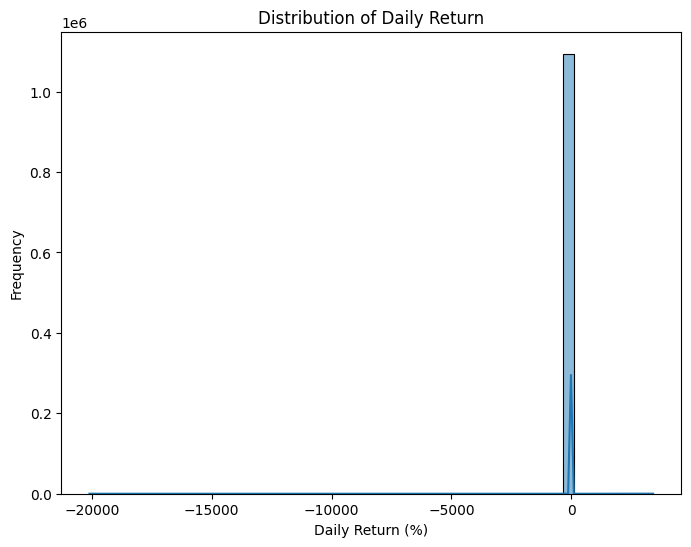

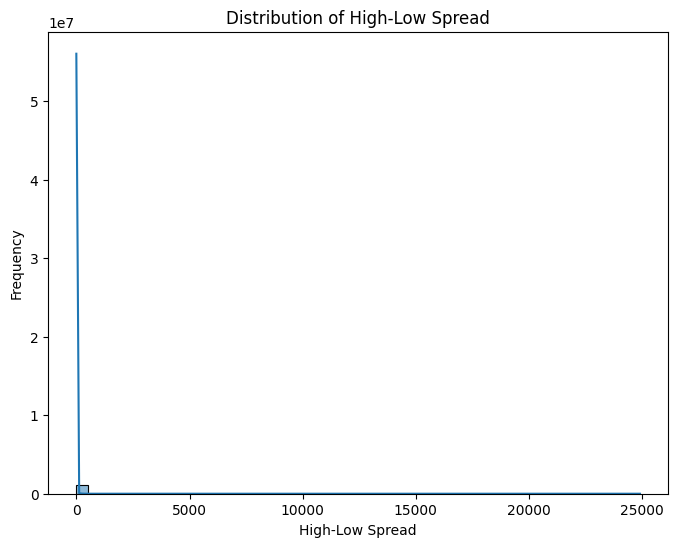

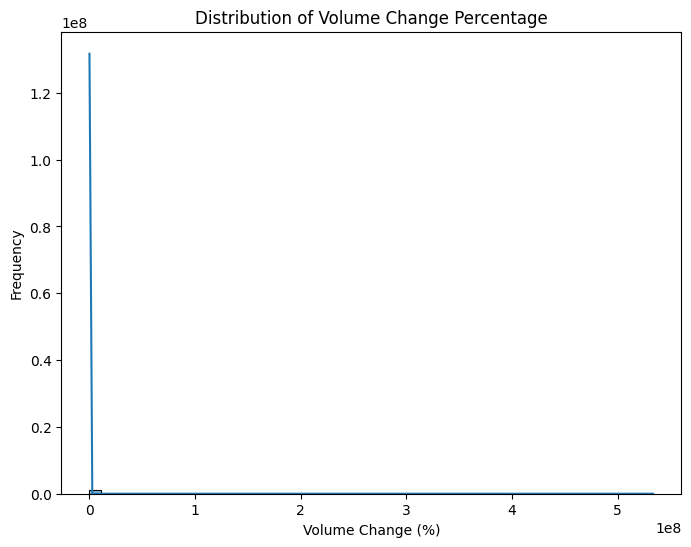

In [11]:
# Plot the distribution of daily return
plt.figure(figsize=(8, 6))
sns.histplot(df['daily_return'], bins=50, kde=True)
plt.title('Distribution of Daily Return')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

# Plot the distribution of high-low spread
plt.figure(figsize=(8, 6))
sns.histplot(df['high_low_spread'], bins=50, kde=True)
plt.title('Distribution of High-Low Spread')
plt.xlabel('High-Low Spread')
plt.ylabel('Frequency')
plt.show()

# Plot the distribution of volume change percentage
plt.figure(figsize=(8, 6))
sns.histplot(df['volume_change_pct'], bins=50, kde=True)
plt.title('Distribution of Volume Change Percentage')
plt.xlabel('Volume Change (%)')
plt.ylabel('Frequency')
plt.show()

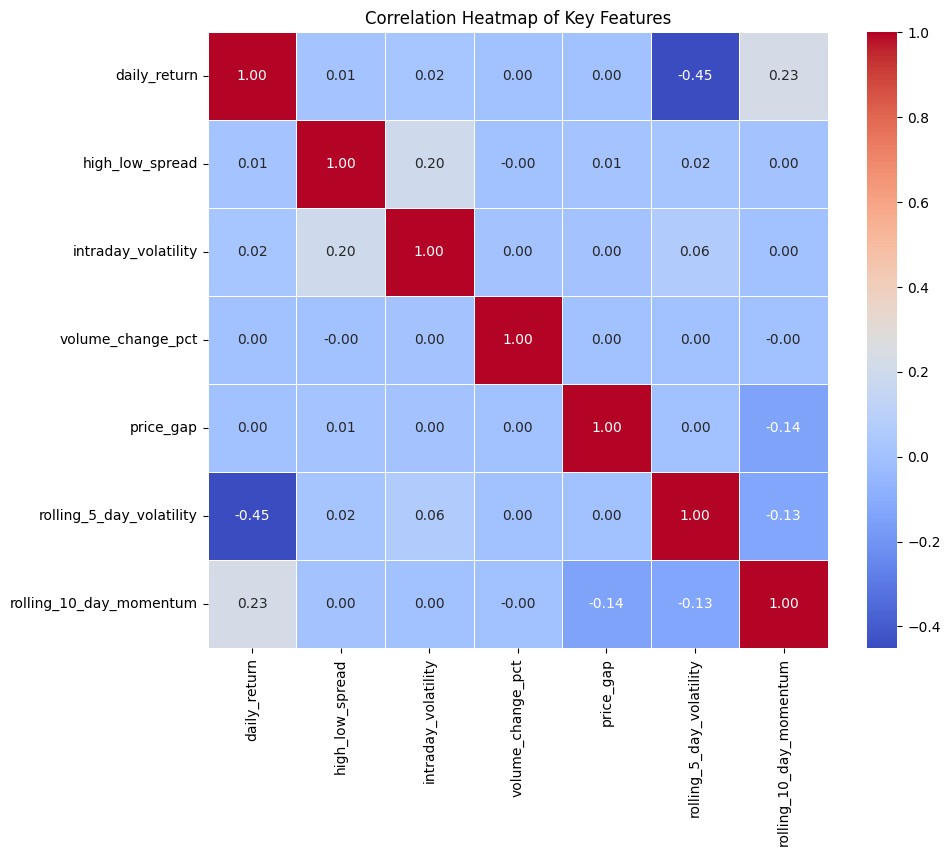

In [4]:
# Correlation matrix of the features
corr_matrix = df[['daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 
                  'price_gap', 'rolling_5_day_volatility', 'rolling_10_day_momentum']].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Features')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_141100\721770732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='market_type', data=df, palette='Set2')


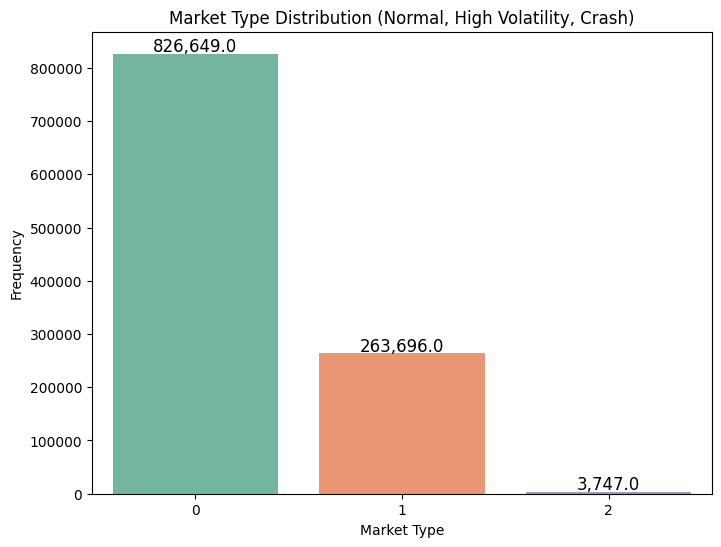

In [6]:
# Plot the distribution of market types with value labels
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='market_type', data=df, palette='Set2')

# Add the value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.title('Market Type Distribution (Normal, High Volatility, Crash)')
plt.xlabel('Market Type')
plt.ylabel('Frequency')
plt.show()

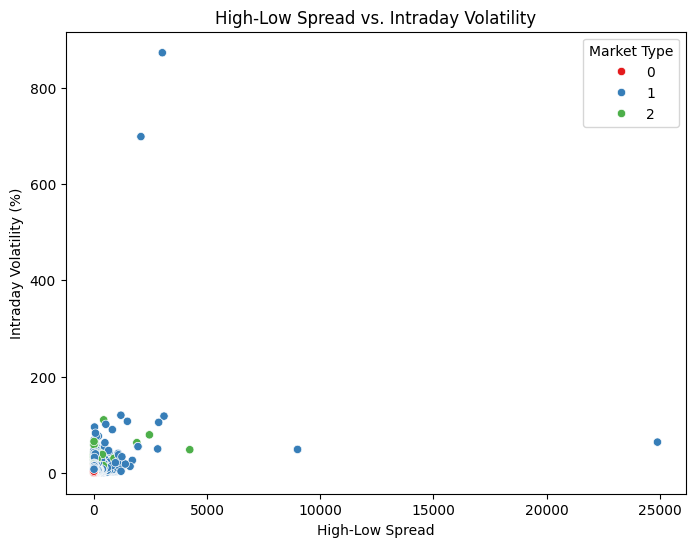

In [9]:
# Scatter plot of high-low spread vs. intraday volatility
plt.figure(figsize=(8, 6))
sns.scatterplot(x='high_low_spread', y='intraday_volatility', data=df, hue='market_type', palette='Set1')
plt.title('High-Low Spread vs. Intraday Volatility')
plt.xlabel('High-Low Spread')
plt.ylabel('Intraday Volatility (%)')
plt.legend(title='Market Type')
plt.show()